In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from pathlib import Path
import sys
import os
from datetime import datetime
from dataScraper import *

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import nameDict


pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('data/props/ev_analysis/underdog.csv')
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')

Over 53.55% | under 46.45%
Mean: 19.91 | Median: 19.89 | Std: 4.19 | Line: 19.50


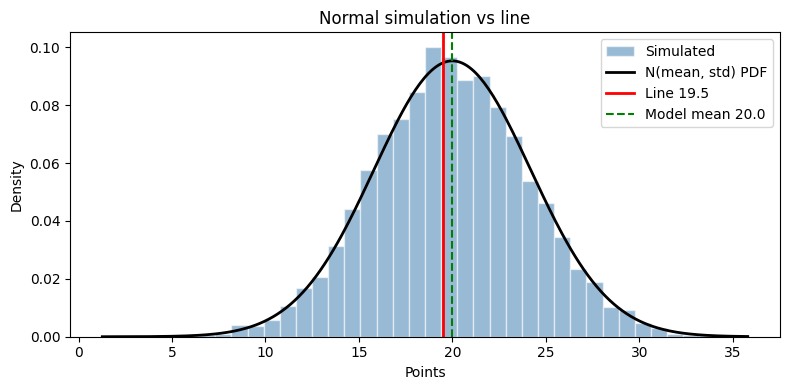

In [7]:
from scipy.stats import norm, poisson
import matplotlib.pyplot as plt

player_prop = df[(df['Player'] == 'LeBron James') & (df['Prop'] == 'PTS')]
pdf = s26[s26['PLAYER_ID'] == 2544]

mean = float(player_prop['Avg Stat L10'].values[0])
std = float(pdf['PTS'].tail(20).std())
line = float(player_prop['Line'].values[0])

rng = np.random.default_rng()
samples = rng.normal(mean, std, 10_000)

over_prob = (samples > line).mean()
under_prob = (samples < line).mean()

print(f"Over {over_prob:.2%} | under {under_prob:.2%}")
print(
    f"Mean: {samples.mean():.2f} | Median: {np.median(samples):.2f} | "
    f"Std: {std:.2f} | Line: {line:.2f}"
)

# --- Visual ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(samples, bins=40, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="Simulated")

xs = np.linspace(samples.min(), samples.max(), 300)
ax.plot(xs, norm.pdf(xs, loc=mean, scale=std), color="black", lw=2, label="N(mean, std) PDF")

ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(mean, color="green", ls="--", lw=1.5, label=f"Model mean {mean:.1f}")
ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title("Normal simulation vs line")
ax.legend()
plt.tight_layout()
plt.show()



Over 39.97% | under 60.03%
Mean: 20.01 | Median: 19.00 | Hist std: 4.47 | Line: 19.50 | n_games: 10


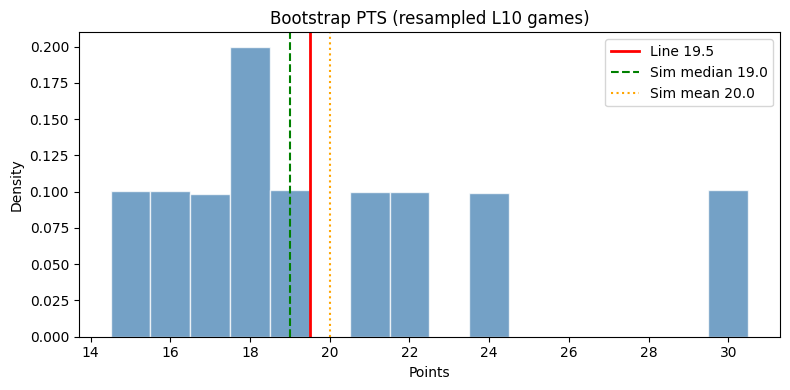

In [8]:
import numpy as np
import matplotlib.pyplot as plt

player_prop = df[(df['Player'] == 'LeBron James') & (df['Prop'] == 'PTS')]
pdf = s26[s26['PLAYER_ID'] == 2544]

pts_history = pd.to_numeric(pdf['PTS'].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for bootstrap.")

n_sims = 100_000
rng = np.random.default_rng()
samples = rng.choice(pts_history, size=n_sims, replace=True)

line = float(player_prop['Line'].values[0])
over_prob = (samples > line).mean()
under_prob = (samples < line).mean()

print(f"Over {over_prob:.2%} | under {under_prob:.2%}")
print(
    f"Mean: {samples.mean():.2f} | Median: {np.median(samples):.2f} | "
    f"Hist std: {pts_history.std(ddof=1):.2f} | Line: {line:.2f} | n_games: {len(pts_history)}"
)

# --- Visual ---
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(samples.min() - 0.5, samples.max() + 1.5, 1)  # integer PTS bins
ax.hist(samples, bins=bins, density=True, alpha=0.75, color="steelblue", edgecolor="white")
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(np.median(samples), color="green", ls="--", lw=1.5, label=f"Sim median {np.median(samples):.1f}")
ax.axvline(np.mean(samples), color="orange", ls=":", lw=1.5, label=f"Sim mean {np.mean(samples):.1f}")
ax.set_xlabel("Points")
ax.set_ylabel("Density")
ax.set_title("Bootstrap PTS (resampled L10 games)")
ax.legend()
plt.tight_layout()
plt.show()

Negative binomial (MoM fit on L10 PTS; scipy parameterization n, p)
  Fitted n=20000.000, p=0.9990 | NB mean=20.00, var=20.02
Over 53.10% | under 46.90%
Mean: 20.01 | Median: 20.00 | Line: 19.50 | n_games: 10


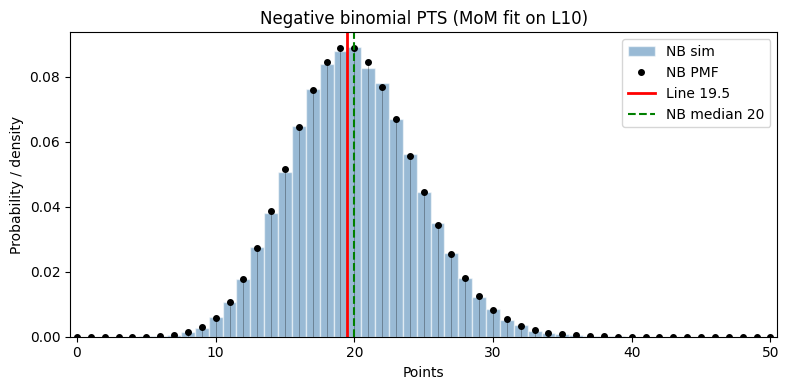

In [9]:
from scipy.stats import nbinom

player_prop = df[(df['Player'] == 'LeBron James') & (df['Prop'] == 'PTS')]
pdf = s26[s26['PLAYER_ID'] == 2544]

pts_history = pd.to_numeric(pdf['PTS'].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for NB fit.")

mu = float(np.mean(pts_history))
var = float(np.var(pts_history, ddof=1)) if len(pts_history) > 1 else mu

# scipy.stats.nbinom: E[X] = n*(1-p)/p, Var[X] = n*(1-p)/p^2  →  p = μ/σ²,  n = μ*p/(1-p)
if var > mu:
    p_nb = mu / var
    n_nb = mu * p_nb / (1.0 - p_nb)
else:
    # Not overdispersed vs NB2; nudge variance slightly so NB is defined
    var_adj = max(var, mu * 1.001)
    p_nb = mu / var_adj
    n_nb = max(mu * p_nb / (1.0 - p_nb), 1e-3)

n_sims = 100_000
rng = np.random.default_rng()
samples_nb = nbinom.rvs(n_nb, p_nb, size=n_sims, random_state=rng)

line = float(player_prop['Line'].values[0])
over_prob = (samples_nb > line).mean()
under_prob = (samples_nb < line).mean()

print("Negative binomial (MoM fit on L10 PTS; scipy parameterization n, p)")
print(f"  Fitted n={n_nb:.3f}, p={p_nb:.4f} | NB mean={nbinom.mean(n_nb, p_nb):.2f}, var={nbinom.var(n_nb, p_nb):.2f}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}")
print(
    f"Mean: {samples_nb.mean():.2f} | Median: {np.median(samples_nb):.2f} | "
    f"Line: {line:.2f} | n_games: {len(pts_history)}"
)

# --- Visual: histogram + fitted PMF ---
k_max = int(max(samples_nb.max(), line) + 8)
ks = np.arange(0, k_max + 1)
pmf = nbinom.pmf(ks, n_nb, p_nb)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, k_max + 1.5, 1)
ax.hist(samples_nb, bins=bins, density=True, alpha=0.55, color="steelblue", edgecolor="white", label="NB sim")
ax.plot(ks, pmf, "ko", ms=4, label="NB PMF")
ax.vlines(ks, 0, pmf, colors="black", lw=0.6, alpha=0.35)
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(nbinom.median(n_nb, p_nb), color="green", ls="--", lw=1.5, label=f"NB median {nbinom.median(n_nb, p_nb):.0f}")
ax.set_xlabel("Points")
ax.set_ylabel("Probability / density")
ax.set_title("Negative binomial PTS (MoM fit on L10)")
ax.set_xlim(-0.5, k_max + 0.5)
ax.legend()
plt.tight_layout()
plt.show()

Poisson (λ = mean of L10 PTS)
  λ=20.000 | Poisson mean=20.00, var=20.00
Over 53.25% | under 46.75%
Mean: 20.02 | Median: 20.00 | Line: 19.50 | n_games: 10


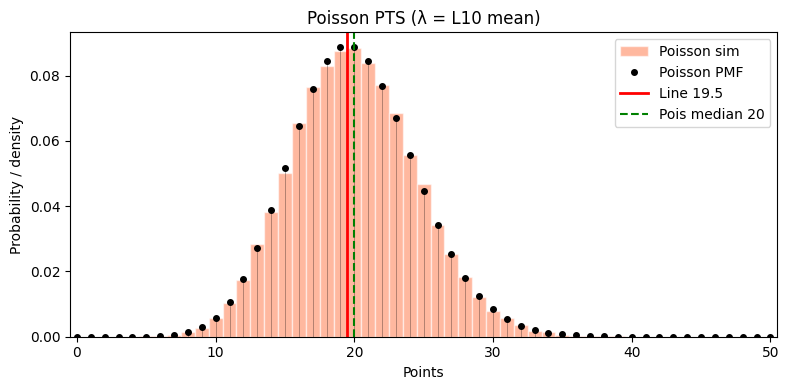

In [10]:
from scipy.stats import poisson

player_prop = df[(df['Player'] == 'LeBron James') & (df['Prop'] == 'PTS')]
pdf = s26[s26['PLAYER_ID'] == 2544]

pts_history = pd.to_numeric(pdf['PTS'].tail(10), errors="coerce").dropna().values
if len(pts_history) < 3:
    raise ValueError("Need a few games in pts_history for Poisson rate.")

# Poisson: single parameter λ ≈ historical mean (same window as L10 bootstrap/NB)
lam = float(np.mean(pts_history))

n_sims = 100_000
rng = np.random.default_rng()
samples_pois = rng.poisson(lam, size=n_sims)

line = float(player_prop['Line'].values[0])
over_prob = (samples_pois > line).mean()
under_prob = (samples_pois < line).mean()

print("Poisson (λ = mean of L10 PTS)")
print(f"  λ={lam:.3f} | Poisson mean={poisson.mean(lam):.2f}, var={poisson.var(lam):.2f}")
print(f"Over {over_prob:.2%} | under {under_prob:.2%}")
print(
    f"Mean: {samples_pois.mean():.2f} | Median: {np.median(samples_pois):.2f} | "
    f"Line: {line:.2f} | n_games: {len(pts_history)}"
)

# --- Visual ---
k_max = int(max(samples_pois.max(), line) + 8)
ks = np.arange(0, k_max + 1)
pmf = poisson.pmf(ks, lam)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, k_max + 1.5, 1)
ax.hist(samples_pois, bins=bins, density=True, alpha=0.55, color="coral", edgecolor="white", label="Poisson sim")
ax.plot(ks, pmf, "ko", ms=4, label="Poisson PMF")
ax.vlines(ks, 0, pmf, colors="black", lw=0.6, alpha=0.35)
ax.axvline(line, color="red", lw=2, label=f"Line {line:g}")
ax.axvline(poisson.median(lam), color="green", ls="--", lw=1.5, label=f"Pois median {poisson.median(lam):.0f}")
ax.set_xlabel("Points")
ax.set_ylabel("Probability / density")
ax.set_title("Poisson PTS (λ = L10 mean)")
ax.set_xlim(-0.5, k_max + 0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Bayesian update for a player's scoring rate
# Prior: Normal(mu_0, sigma_0) from season average or career data
# Likelihood: observed game scores
# Posterior: updated Normal distribution
from scipy import stats

def bayesian_projection(
    prior_mean: float,      # season average
    prior_std: float,       # uncertainty in that average
    observations: list,     # recent game scores
    obs_noise: float        # known game-to-game variance (std dev)
) -> tuple[float, float]:
    """
    Conjugate Normal-Normal Bayesian update.
    Returns (posterior_mean, posterior_std).
    
    prior_std:  how uncertain you are about the player's true rate
                (smaller = more confident in season average)
    obs_noise:  the player's game-to-game variance (use rolling 20-game std)
    """
    n = len(observations)
    obs_mean = np.mean(observations)
    
    # Precision = 1 / variance
    prior_precision = 1 / prior_std**2
    obs_precision   = n / obs_noise**2
    
    posterior_precision = prior_precision + obs_precision
    posterior_std       = np.sqrt(1 / posterior_precision)
    
    posterior_mean = (
        (prior_precision * prior_mean + obs_precision * obs_mean)
        / posterior_precision
    )
    
    return posterior_mean, posterior_std

# Example:
# Season average 24.3 (confident — low prior_std)
# Last 7 games averaging 28.9 (might be noise or real change)
post_mean, post_std = bayesian_projection(
    prior_mean=pdf['PTS'].mean(),
    prior_std=pdf['PTS'].std() / len(pdf),       # fairly confident in the season rate
    observations=pdf['PTS'].tail(10).values,
    obs_noise=pdf['PTS'].tail(20).std()        # this player's game-to-game std
)
print(f"Posterior: {post_mean:.2f} ± {post_std:.2f}")
# → 25.8 ± 1.7  (pulled toward prior, not fully trusting the hot streak)


Posterior: 21.32 ± 0.12


In [21]:
import pymc as pm
import numpy as np

def build_hierarchical_pts_model(player_game_scores: dict):
    """
    player_game_scores: {'LeBron': [28, 31, ...], 'AD': [22, 18, ...], ...}
    
    Estimates each player's true scoring rate, pooling info across all players.
    Players with fewer games borrow more from the group.
    """
    players = list(player_game_scores.keys())
    n_players = len(players)
    obs_list  = [np.array(player_game_scores[p]) for p in players]
    
    with pm.Model() as model:
        # League-level hyperpriors
        mu_league    = pm.Normal("mu_league", mu=20, sigma=8)
        sigma_league = pm.HalfNormal("sigma_league", sigma=5)
        
        # Player-level true scoring rates — drawn from league distribution
        mu_player = pm.Normal(
            "mu_player",
            mu=mu_league,
            sigma=sigma_league,
            shape=n_players
        )
        
        # Game-to-game variance (shared across players for simplicity,
        # or model per-player if you have enough data)
        sigma_game = pm.HalfNormal("sigma_game", sigma=6)
        
        # Likelihood — observed game scores
        for i, obs in enumerate(obs_list):
            pm.Normal(
                f"obs_{i}",
                mu=mu_player[i],
                sigma=sigma_game,
                observed=obs
            )
        
        # Sample from posterior
        trace = pm.sample(2000, tune=1000, return_inferencedata=True)
    
    return trace, players
player_game_scores = {
    "LeBron James": pdf["PTS"].tail(15).tolist(),
}
trace, players = build_hierarchical_pts_model(player_game_scores)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_league, sigma_league, mu_player, sigma_game]


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
There were 684 divergences after tuning. Increase `target_accept` or reparameterize.


In [23]:
import pymc as pm
import numpy as np

def detect_scoring_changepoint(scores: list) -> dict:
    """
    Detects if there's a point in the season where the player's
    scoring rate structurally changed.
    
    Returns the most likely changepoint game index and
    pre/post means with uncertainty.
    """
    scores = np.array(scores)
    n = len(scores)
    
    with pm.Model() as model:
        # Changepoint location — uniform prior over all games
        tau = pm.DiscreteUniform("tau", lower=3, upper=n-3)
        
        # Pre and post changepoint means
        mu_early = pm.Normal("mu_early", mu=np.mean(scores), sigma=8)
        mu_late  = pm.Normal("mu_late",  mu=np.mean(scores), sigma=8)
        sigma    = pm.HalfNormal("sigma", sigma=6)
        
        # Expected value switches at tau
        mu = pm.math.switch(tau >= np.arange(n), mu_early, mu_late)
        
        obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=scores)
        
        trace = pm.sample(1000, tune=500, return_inferencedata=True,
                         target_accept=0.9)
    
    tau_samples   = trace.posterior["tau"].values.flatten()
    early_samples = trace.posterior["mu_early"].values.flatten()
    late_samples  = trace.posterior["mu_late"].values.flatten()
    
    return {
        "changepoint_game":  int(np.median(tau_samples)),
        "pre_change_mean":   float(np.mean(early_samples)),
        "post_change_mean":  float(np.mean(late_samples)),
        "mean_shift":        float(np.mean(late_samples - early_samples)),
        "shift_certain":     float(np.mean(np.abs(late_samples - early_samples) > 3))
    }
pts = pdf.sort_values("GAME_DATE")["PTS"].astype(float).tolist()
# or last 30 games only:
# pts = pdf.sort_values("GAME_DATE")["PTS"].tail(30).astype(float).tolist()

out = detect_scoring_changepoint(pts)
out

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_early, mu_late, sigma]


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


{'changepoint_game': 5,
 'pre_change_mean': 15.808635636091866,
 'post_change_mean': 22.15420759725076,
 'mean_shift': 6.345571961158895,
 'shift_certain': 0.8655}

In [24]:
import numpy as np
import pymc as pm

y = np.array([22, 28, 19, 24, 30], dtype=int)  # integer points

with pm.Model() as model:
    # Expected points (must be > 0)
    mu = pm.HalfNormal("mu", sigma=15)

    # Extra variance vs Poisson; try HalfNormal(1–3) and check prior pred
    alpha = pm.HalfNormal("alpha", sigma=2)

    pm.NegativeBinomial("obs", mu=mu, alpha=alpha, observed=y)

    idata = pm.sample(1000, tune=1000, target_accept=0.9, random_seed=42)

mu_draws = idata.posterior["mu"].values.ravel()
print("Posterior mean of μ:", float(mu_draws.mean()))
print("μ 95% interval:", np.quantile(mu_draws, [0.025, 0.975]))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, alpha]


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Posterior mean of μ: 23.032085573706535
μ 95% interval: [13.94365364 35.33795359]
